In [2]:
import torch
import matplotlib.pyplot as plt

In [7]:
T = 1000
t = torch.arange(T+1)
normalized_t = torch.arange(T+1) / T

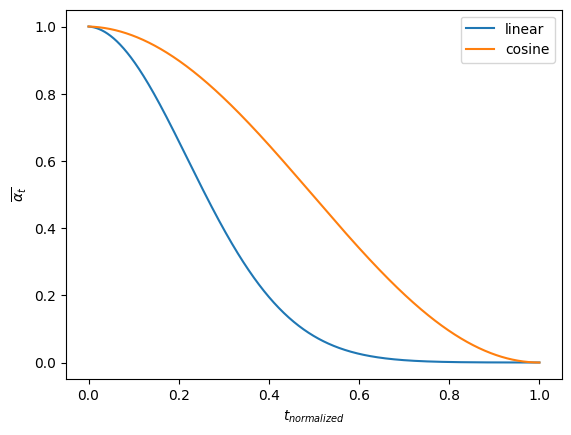

In [9]:
# Linear Scheduler
beta_start = 1e-4
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end, T)
alphas = 1. - betas
alpha_bars = torch.cumprod(alphas, dim=0)
alpha_bars = torch.cat([torch.tensor([1.0]), alpha_bars])
plt.plot(normalized_t, alpha_bars, label="linear")
plt.xlabel(r"$t_{normalized}$", fontsize=10)
plt.ylabel(r"$\overline{\alpha_t}$", fontsize=10)

# Cosine Scheduler
s = 0.008
t = torch.arange(0, T+1, dtype=torch.float32)
f_t = torch.square(torch.cos(((t/T) + s) / (1+s) * torch.pi / 2))
alpha_bars = f_t / f_t[0]
plt.plot(normalized_t, alpha_bars, label="cosine")

plt.legend();

The linear noise schedule works well for high resolution images but is sub-optimal for images of resolutions 64x64 and 32x32. In particular, the end of the forward noising process is too noisy, and so doesn't contribute much to sample quality. This can be visually seen in the plotted figure.